# Cepheid — model & spectrum build

Builds the mesh bundles and the synthetic spectra needed for the radial-velocity analysis (see `cepheid_analysis.ipynb`). Everything is constructed from scratch and written to disk:

- `cepheid_bundles.pkl` — a `dict[str, CepheidBundle]` with one entry per emulator variant.
- `cepheid_spectra.pkl` — a `dict[str, dict[float, LineSpectra]]` keyed by `(variant, line_center)`.

`CepheidBundle` and `LineSpectra` live in `cepheid_bundles.py` next to this notebook so pickle can resolve them by stable import path. Both notebooks should sit in the same directory; `sys.path` is patched below to make the module importable.


In [1]:
import sys, os
sys.path.append('/Users/mjablons/code/spice/src')
sys.path.append(os.path.dirname(os.path.abspath('cepheid_bundles.py')))

import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
from tqdm import tqdm
from astropy.io import fits
from astropy.table import Table
from scipy import optimize
from scipy.interpolate import interp1d

from spice.spectrum.lazy_zarr_interpolator import (
    IntensityLazyZarrInterpolator, FluxLazyZarrInterpolator,
)
from cepheid_bundles import (
    CepheidBundle, LineSpectra,
    build_bundle, apply_phase_params, simulate_line_spectra,
    save_pickle,
)

%matplotlib inline


## Spectrum emulators

We build three families of mesh models:

- `intensity` — `IntensityLazyZarrInterpolator` (11 params: stellar params + per-face `mu`). This is the only emulator we'll feed into the spectrum-synthesis loop, because synthesis needs an intensity function.
- `flux_no_ld` — `FluxLazyZarrInterpolator` with limb-darkening coefficients that disable LD (`[1.0, 1.0, 0., 0.]`).
- `flux_linear_<c>` — `FluxLazyZarrInterpolator` with linear LD law and a few sampled coefficients. Useful for flux-level comparisons; not used for spectrum synthesis here.


In [2]:
LINE_INTERP_PATH = '/Users/mjablons/code/spice/data/fe_nlte_intensity.zarr'
FLUX_INTERP_PATH = '/Users/mjablons/code/spice/data/fe_nlte_flux.zarr'

INTENSITY_PARAMS = ['teff', 'logg', '[Fe/H]', 'vmicro', '[a/Fe]',
                    '[C/Fe]', '[N/Fe]', '[O/Fe]', '[r/Fe]', '[s/Fe]', 'mu']
FLUX_PARAMS      = ['teff', 'logg', '[Fe/H]', 'vmicro', '[a/Fe]',
                    '[C/Fe]', '[N/Fe]', '[O/Fe]', '[r/Fe]', '[s/Fe]']

SOLAR_INTENSITY = np.array([5777, 4.44, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])
SOLAR_FLUX      = np.array([5777, 4.44, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

intensity_emulator = IntensityLazyZarrInterpolator(
    LINE_INTERP_PATH, params=INTENSITY_PARAMS, solar_parameters=SOLAR_INTENSITY,
    sparse=True, in_memory=False,
)

flux_no_ld_emulator = FluxLazyZarrInterpolator(
    FLUX_INTERP_PATH, params=FLUX_PARAMS, solar_parameters=SOLAR_FLUX,
    sparse=True, in_memory=False,
    limb_darkening_law='linear',
    limb_darkening_coeffs=jnp.array([0.0]),
)

LD_COEFFS = np.linspace(0.0, 1.0, 10)  # sampled linear-LD coefficients
flux_linear_emulators = {
    c: FluxLazyZarrInterpolator(
        FLUX_INTERP_PATH, params=FLUX_PARAMS, solar_parameters=SOLAR_FLUX,
        sparse=True, in_memory=False,
        limb_darkening_law='linear',
        limb_darkening_coeffs=jnp.array([c, 0.0, 0., 0.]),
    )
    for c in LD_COEFFS
}


[spice] zarr loaded in 0.5 s
Building sparse grid index...
Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 1.4 s
Building sparse grid index...
Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 0.1 s
Building sparse grid index...
Sparse grid index ready.


...

[spice] Spectral grid loaded in 0.0 s
Building sparse grid index...
Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 0.1 s
Building sparse grid index...
Sparse grid index ready.


[spice] Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

[spice] Spectral grid loaded in 0.0 s


## SPIPS3 templates for Delta Cephei


In [3]:
with fits.open('delta_cep.fits', ignore_missing_simple=True) as hdul:
    hdul.info()
    model_data = Table(hdul[1].data)
    pulsation_data = Table(hdul[2].data)

print(f"Starting radius:  {pulsation_data['R'][0]:.3f} R_sun")
print(f"Starting Teff:    {pulsation_data['Teff'][0]:.1f} K")
print(f"Starting log g:   {pulsation_data['logg'][0]:.3f}")


Filename: delta_cep.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     354   ()      
  1  DATA          1 BinTableHDU     29   994R x 7C   [D, 52A, E, E, E, E, D]   
  2  MODEL         1 BinTableHDU     75   1000R x 27C   [E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E, E]   
Starting radius:  41.178 R_sun
Starting Teff:    6562.0 K
Starting log g:   1.883


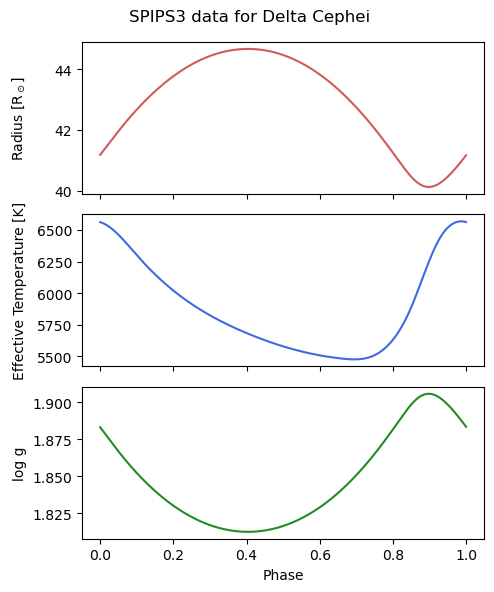

In [4]:
fig, axs = plt.subplots(3, 1, figsize=(5, 6), sharex=True)
fig.suptitle('SPIPS3 data for Delta Cephei')
axs[0].plot(pulsation_data['PHASE'], pulsation_data['R'],    color='indianred')
axs[0].set_ylabel(r'Radius [R$_\odot$]')
axs[1].plot(pulsation_data['PHASE'], pulsation_data['Teff'], color='royalblue')
axs[1].set_ylabel('Effective Temperature [K]')
axs[2].plot(pulsation_data['PHASE'], pulsation_data['logg'], color='forestgreen')
axs[2].set_xlabel('Phase'); axs[2].set_ylabel('log g')
fig.align_ylabels(axs); plt.tight_layout(); plt.show()


## Fourier decomposition of the radius template

`fourier_series_parameters` has shape `(3, n_terms, 2)` — the three rows are the radial / spheroidal / toroidal vector spherical harmonics components. A Cepheid pulsates in a purely radial $\ell=0$, $m=0$ mode, so only the radial row is non-zero.


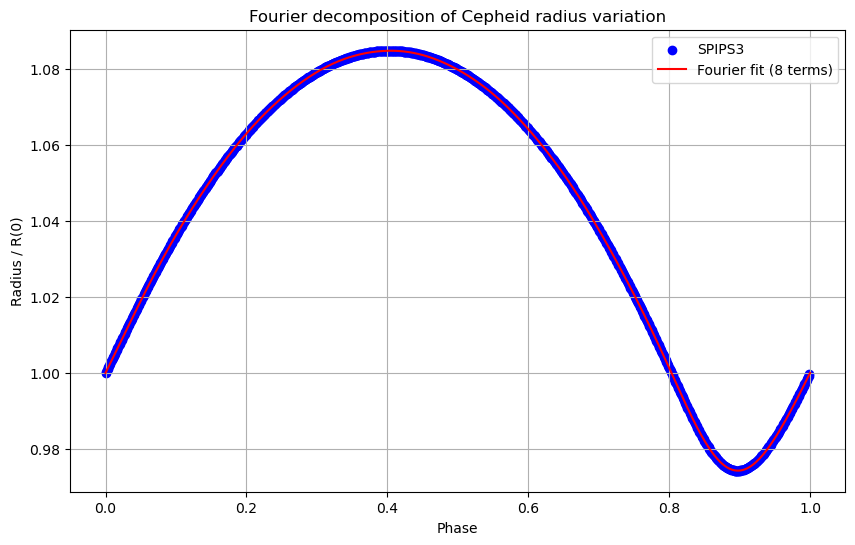

Mean radius (a0): 1.0420
Fourier params shape: (3, 8, 2)


In [5]:
phases_fit = np.array(pulsation_data['PHASE'])
radius_fit_data = np.array(pulsation_data['R'] / pulsation_data['R'][0])
sort_idx = np.argsort(phases_fit)
phases_fit, radius_fit_data = phases_fit[sort_idx], radius_fit_data[sort_idx]

def fourier_series(x, a0, *coeffs):
    n_terms = len(coeffs) // 2
    out = a0
    for i in range(n_terms):
        a_i, b_i = coeffs[2 * i], coeffs[2 * i + 1]
        out = out + a_i * np.cos(2 * np.pi * (i + 1) * x) + b_i * np.sin(2 * np.pi * (i + 1) * x)
    return out

N_TERMS = 8
p0 = [np.mean(radius_fit_data)] + [0.0] * (2 * N_TERMS)
params, _ = optimize.curve_fit(fourier_series, phases_fit, radius_fit_data, p0=p0)
a0, fourier_coeffs = params[0], params[1:]

phase_fine = np.linspace(0, 1, 1000)
plt.figure(figsize=(10, 6))
plt.scatter(phases_fit, radius_fit_data, color='blue', label='SPIPS3')
plt.plot(phase_fine, fourier_series(phase_fine, *params), color='red', label=f'Fourier fit ({N_TERMS} terms)')
plt.xlabel('Phase'); plt.ylabel(r'Radius / R(0)'); plt.legend(); plt.grid(True)
plt.title('Fourier decomposition of Cepheid radius variation'); plt.show()

radial_fourier = np.zeros((N_TERMS, 2))
for i in range(N_TERMS):
    a_i, b_i = fourier_coeffs[2 * i], fourier_coeffs[2 * i + 1]
    radial_fourier[i] = [np.sqrt(a_i ** 2 + b_i ** 2), np.arctan2(b_i, a_i)]

fourier_series_parameters = np.stack([
    radial_fourier,                  # radial
    np.zeros_like(radial_fourier),   # spheroidal
    np.zeros_like(radial_fourier),   # toroidal
])

PERIOD = 5.366265401100268
print(f"Mean radius (a0): {a0:.4f}")
print(f"Fourier params shape: {fourier_series_parameters.shape}")


## Build the mesh bundles

Stellar parameters (Nardetto et al. 2024; Luck 2018; Takeda 2013; Lemasle et al. 2013; Genovali et al. 2015; Gillet et al. 1999):
- N_mesh=5000, R=43.06 R☉, M=5.26 M☉
- Teff, log g: phase-0 SPIPS3 values
- [Fe/H]=+0.06, vmicro=3.5 km/s, [α/H]=+0.05, [C/Fe]=-0.25, [N/Fe]=+0.4, [O/Fe]=0, [r/Fe]=0, [s/Fe]=+0.15


In [6]:
TIMESERIES = jnp.linspace(0, PERIOD, 100)

stellar_params_dict = {
    'teff':    pulsation_data['Teff'][0],
    'logg':    pulsation_data['logg'][0],
    '[Fe/H]':  0.06,
    'vmicro':  3.5,
}

# (emulator, params, param_names_attr)
BUNDLE_CONFIGS = {
    'intensity':   (intensity_emulator, intensity_emulator.to_parameters(stellar_params_dict), 'stellar_parameter_names'),
}
for c in LD_COEFFS:
    name = f'flux_linear_{c:.1f}'
    BUNDLE_CONFIGS[name] = (
        flux_linear_emulators[c],
        flux_linear_emulators[c].to_parameters(stellar_params_dict),
        'stellar_parameter_names',
    )

print('Will build:', list(BUNDLE_CONFIGS.keys()))


Will build: ['intensity', 'flux_linear_0.0', 'flux_linear_0.1', 'flux_linear_0.2', 'flux_linear_0.3', 'flux_linear_0.4', 'flux_linear_0.6', 'flux_linear_0.7', 'flux_linear_0.8', 'flux_linear_0.9', 'flux_linear_1.0']


In [7]:
bundles: dict[str, CepheidBundle] = {}
for name, (emul, params, attr) in BUNDLE_CONFIGS.items():
    print(f'Building {name}...')
    bundles[name] = build_bundle(
        emul, params,
        fourier_params=fourier_series_parameters,
        period=PERIOD, timeseries=TIMESERIES,
        param_names_attr=attr,
        desc=f'Evaluating {name}',
    )
print('Done.')


Building intensity...
[spice] IcosphereModel constructed in 1.1 s


[spice] Pulsations evaluated in 2.9 s                        
[spice] Pulsations evaluated in 0.4 s                                
[spice] Pulsations evaluated in 0.8 s                                
[spice] Pulsations evaluated in 0.8 s                                
[spice] Pulsations evaluated in 0.8 s                                
[spice] Pulsations evaluated in 0.8 s                                
[spice] Pulsations evaluated in 0.8 s                                
[spice] Pulsations evaluated in 0.8 s                                
[spice] Pulsations evaluated in 0.8 s                                
[spice] Pulsations evaluated in 0.8 s                                
[spice] Pulsations evaluated in 0.7 s                                 
[spice] Pulsations evaluated in 0.9 s                                 
[spice] Pulsations evaluated in 0.8 s                                 
[spice] Pulsations evaluated in 0.8 s                                 
[spice] Pulsations evalu

Building flux_linear_0.0...
[spice] IcosphereModel constructed in 0.2 s


[spice] Pulsations evaluated in 0.0 s                              
[spice] Pulsations evaluated in 0.8 s                              
[spice] Pulsations evaluated in 0.8 s                                      
[spice] Pulsations evaluated in 0.8 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.8 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.9 s                                      
[spice] Pulsations evaluated in 0.8 s                                      
[spice] Pulsations evaluated in 0.8 s                                       
[spice] Pulsations evaluated in 0.7 s                                       
[spice] Pulsations evaluated in 0.7 s                                       
[spice] Pulsations evalua

Building flux_linear_0.1...
[spice] IcosphereModel constructed in 0.7 s


...

Building flux_linear_0.9...
[spice] IcosphereModel constructed in 0.7 s


[spice] Pulsations evaluated in 0.0 s                              
[spice] Pulsations evaluated in 0.7 s                              
[spice] Pulsations evaluated in 0.8 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.6 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.6 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.8 s                                       
[spice] Pulsations evaluated in 0.7 s                                       
[spice] Pulsations evaluated in 0.7 s                                       
[spice] Pulsations evalua

Building flux_linear_1.0...
[spice] IcosphereModel constructed in 0.8 s


[spice] Pulsations evaluated in 0.0 s                              
[spice] Pulsations evaluated in 0.8 s                              
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.8 s                                      
[spice] Pulsations evaluated in 0.8 s                                      
[spice] Pulsations evaluated in 0.7 s                                      
[spice] Pulsations evaluated in 0.9 s                                      
[spice] Pulsations evaluated in 0.7 s                                       
[spice] Pulsations evaluated in 0.6 s                                       
[spice] Pulsations evaluated in 0.7 s                                       
[spice] Pulsations evalua

Done.


## Apply phase-dependent Teff and log g

Interpolate the SPIPS3 templates onto our coarser sampling, then push them into every bundle's snapshots in one loop.


In [8]:
phase_data = np.asarray(pulsation_data['PHASE'])
sort_idx   = np.argsort(phase_data)
phase_sorted = phase_data[sort_idx]
teff_sorted  = np.asarray(pulsation_data['Teff'])[sort_idx]
logg_sorted  = np.asarray(pulsation_data['logg'])[sort_idx]

teff_interp = interp1d(phase_sorted, teff_sorted, kind='cubic', bounds_error=False,
                       fill_value=(teff_sorted[-1], teff_sorted[0]), assume_sorted=True)
logg_interp = interp1d(phase_sorted, logg_sorted, kind='cubic', bounds_error=False,
                       fill_value=(logg_sorted[-1], logg_sorted[0]), assume_sorted=True)

teff_at = lambda p: float(teff_interp(p % 1.0))
logg_at = lambda p: float(logg_interp(p % 1.0))

phases_per_snapshot = [(t % PERIOD) / PERIOD for t in TIMESERIES]

# Param indices: 0 = teff, 1 = logg (same ordering for intensity and flux schemes).
for name, bundle in bundles.items():
    bundles[name] = apply_phase_params(
        bundle, phases_per_snapshot,
        modifiers=[(0, teff_at), (1, logg_at)],
    )
print('Phase-dependent Teff/logg applied.')


Phase-dependent Teff/logg applied.


In [9]:
save_pickle(bundles, 'cepheid_bundles.pkl')
print('Saved cepheid_bundles.pkl with bundles:', list(bundles.keys()))


Saved cepheid_bundles.pkl with bundles: ['intensity', 'flux_linear_0.0', 'flux_linear_0.1', 'flux_linear_0.2', 'flux_linear_0.3', 'flux_linear_0.4', 'flux_linear_0.6', 'flux_linear_0.7', 'flux_linear_0.8', 'flux_linear_0.9', 'flux_linear_1.0']


## Synthesise spectra (5000–5020 Å)

One wavelength window per variant, evaluated at every phase snapshot. Variants:

- `with_ld` — `intensity_emulator.intensity` evaluated at each face's projected `mu` (intensity-grid LD).
- `flux_no_ld`, `flux_linear_<c>` — `FluxLazyZarrInterpolator.intensity` on the matching mesh. LD comes from the linear law plus the emulator's `limb_darkening_coeffs`. Note: despite its legacy name, `flux_no_ld` was configured with `[1.0, 1.0, 0, 0]` — i.e., maximum-strength linear LD (u=1.0).

Synthesis is the slow step.

In [11]:
WL_MIN, WL_MAX = 5000.0, 5020.0
WL_STEPS = 2000

# Each variant pairs an intensity function with the bundle whose parameter
# scheme matches that emulator. The intensity bundle uses the 11-param scheme
# (with mu); the flux bundles use the 10-param scheme and the LD law baked
# into FluxLazyZarrInterpolator.intensity().
SPECTRUM_VARIANTS = [
    ('with_ld',    intensity_emulator.intensity, bundles['intensity']),
]
for c in LD_COEFFS:
    name = f'flux_linear_{c:.1f}'
    SPECTRUM_VARIANTS.append((name, flux_linear_emulators[c].intensity, bundles[name]))

line_center = 0.5 * (WL_MIN + WL_MAX)
line_width = 0.5 * (WL_MAX - WL_MIN)

spectra_dataset: dict[str, dict[float, LineSpectra]] = {}
for name, intensity_fn, bundle in SPECTRUM_VARIANTS:
    print(f'Synthesising {name} spectra...')
    spectra_dataset[name] = simulate_line_spectra(
        bundle.snapshots, bundle.snapshots[0], intensity_fn, (line_center,),
        line_width=line_width, steps=WL_STEPS,
    )

Synthesising with_ld spectra...


lines:   0%|          | 0/1 [00:00<?, ?it/s]/Users/mjablons/anaconda3/envs/astro/lib/python3.11/site-packages/jax/_src/numpy/array_methods.py:124: UserWarning: Explicitly requested dtype <class 'jax.numpy.int64'> requested in astype is not available, and will be truncated to dtype int32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
lines: 100%|██████████| 1/1 [03:35<00:00, 215.59s/it]


Synthesising flux_linear_0.0 spectra...


lines: 100%|██████████| 1/1 [02:08<00:00, 128.35s/it]


Synthesising flux_linear_0.1 spectra...


...

lines: 100%|██████████| 1/1 [02:08<00:00, 128.20s/it]


Synthesising flux_linear_0.9 spectra...


lines: 100%|██████████| 1/1 [02:07<00:00, 127.70s/it]


Synthesising flux_linear_1.0 spectra...


lines: 100%|██████████| 1/1 [02:06<00:00, 126.30s/it]


In [12]:
save_pickle(spectra_dataset, 'cepheid_spectra.pkl')
print('Saved cepheid_spectra.pkl with variants:', list(spectra_dataset.keys()))


Saved cepheid_spectra.pkl with variants: ['with_ld', 'flux_linear_0.0', 'flux_linear_0.1', 'flux_linear_0.2', 'flux_linear_0.3', 'flux_linear_0.4', 'flux_linear_0.6', 'flux_linear_0.7', 'flux_linear_0.8', 'flux_linear_0.9', 'flux_linear_1.0']


Build complete. Move on to `cepheid_analysis.ipynb`.
